

# # Model: SVM




Section to make necessary imports

In [15]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import zipfile
import subprocess

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import hog, local_binary_pattern

Unzipping the dataset file

In [16]:
!unzip -o "/content/student_25029188 (1).zip" -d "/content/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/student_25029188/)/)_100535.jpg  
  inflating: /content/student_25029188/)/)_100647.jpg  
  inflating: /content/student_25029188/)/)_101791.jpg  
  inflating: /content/student_25029188/)/)_102080.jpg  
  inflating: /content/student_25029188/)/)_105100.jpg  
  inflating: /content/student_25029188/)/)_105401.jpg  
  inflating: /content/student_25029188/)/)_106128.jpg  
  inflating: /content/student_25029188/)/)_106306.jpg  
  inflating: /content/student_25029188/)/)_106725.jpg  
  inflating: /content/student_25029188/)/)_107347.jpg  
  inflating: /content/student_25029188/)/)_107649.jpg  
  inflating: /content/student_25029188/)/)_108053.jpg  
  inflating: /content/student_25029188/)/)_108578.jpg  
  inflating: /content/student_25029188/)/)_108592.jpg  
  inflating: /content/student_25029188/)/)_109043.jpg  
  inflating: /content/student_25029188/)/)_109083.jpg  
  inflating: /content/student_25029188/)/)_109172.jpg

In [17]:
import os
print(os.listdir("/content"))

['.config', 'student_25029188 (1).zip', 'student_25029188', 'sample_data']


EDA

In [18]:

import os
import cv2
dataset_path = "/content/student_25029188"

classes = os.listdir(dataset_path)
classes.remove ('metadata.json')
print ("Below are the classes' names and number of images in each class")
print("")
for c in classes:
  print(c, ":", len(os.listdir(os.path.join(dataset_path, c)))
  )

print("")

print("Classes:", classes)
lengthC = len(classes)
print("")
print("There are", lengthC, "classes in this dataset")

Below are the classes' names and number of images in each class

ldots : 500
) : 500
rightarrow : 500
v : 500
theta : 500
0 : 500
= : 500
alpha : 500
p : 500
4 : 500

Classes: ['ldots', ')', 'rightarrow', 'v', 'theta', '0', '=', 'alpha', 'p', '4']

There are 10 classes in this dataset


Loading Images and Labels

In [19]:
import os
import cv2
import numpy as np

images = []
labels = []

dataset_path = "/content/student_25029188"

classes = os.listdir(dataset_path)

for c in classes:
    if c != "metadata.json":

        folder_path = dataset_path + "/" + c

        for file in os.listdir(folder_path):
            img_path = folder_path + "/" + file

            img = cv2.imread(img_path, 0)

            if img is not None:
                img = cv2.resize(img, (45, 45))

                images.append(img)
                labels.append(c)

images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (5000, 45, 45)
Labels shape: (5000,)


The code below displays 3 images per class (3x10 = 30). 30 total images

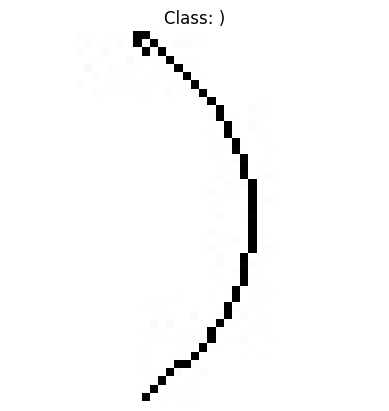

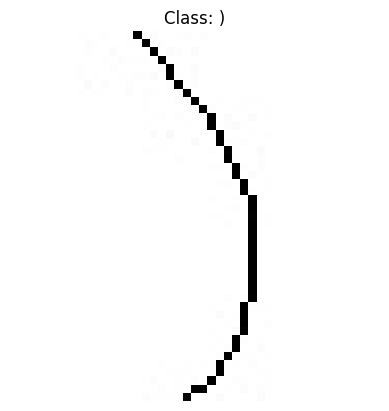

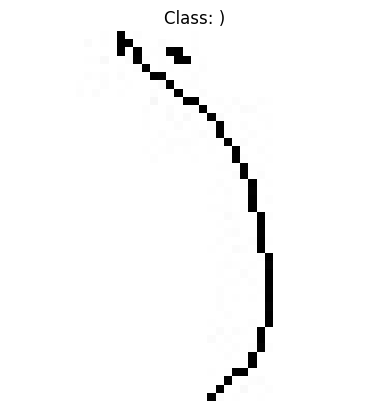

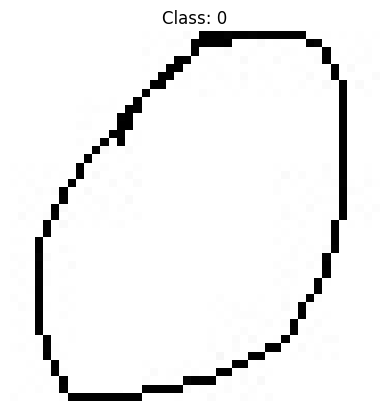

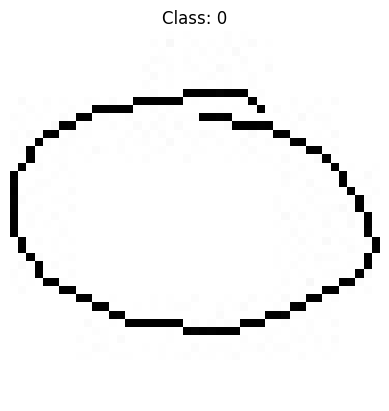

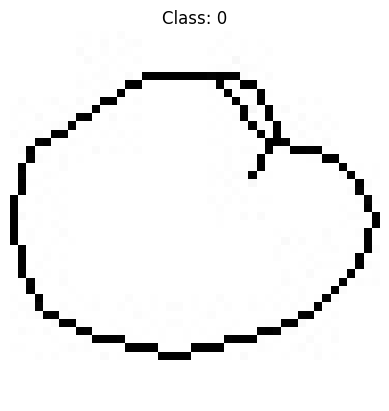

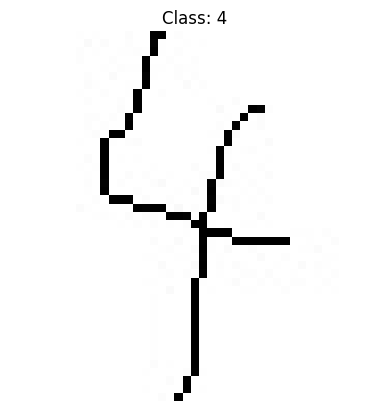

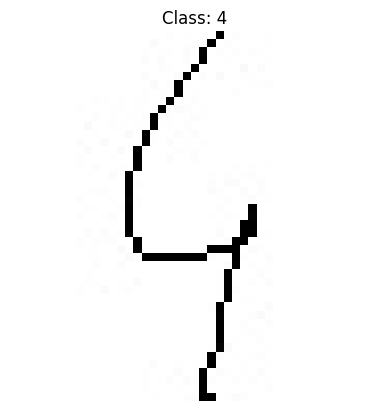

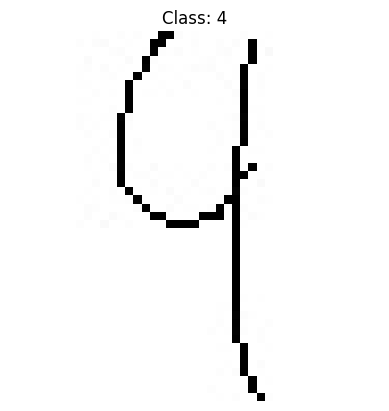

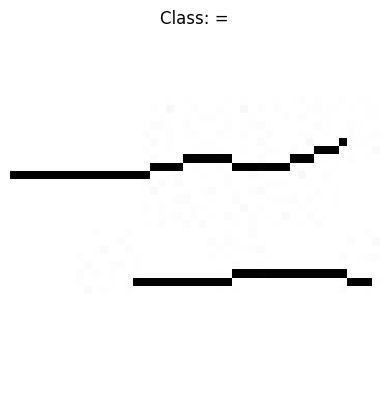

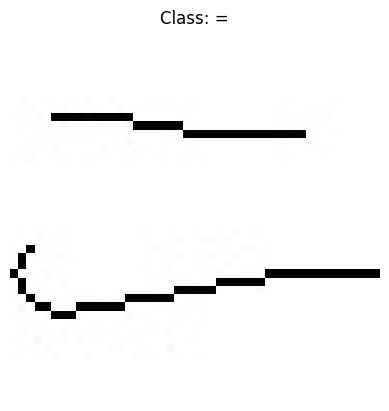

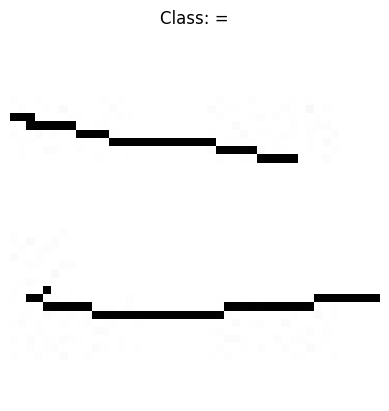

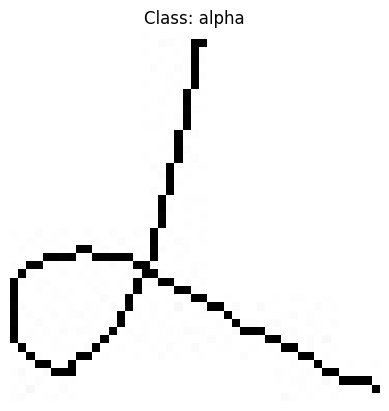

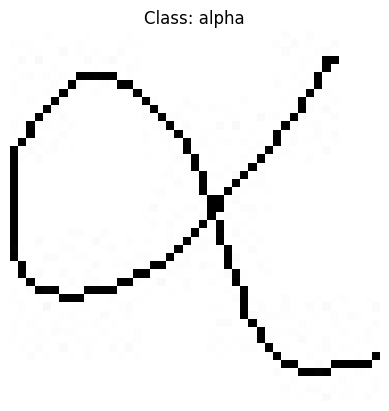

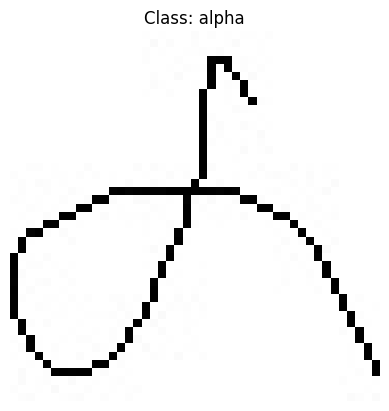

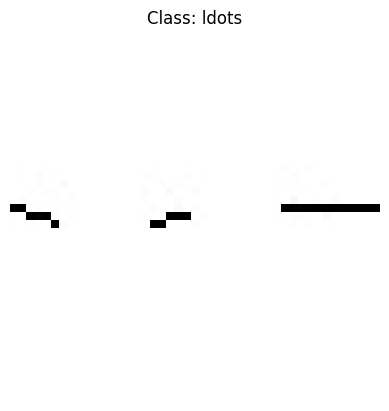

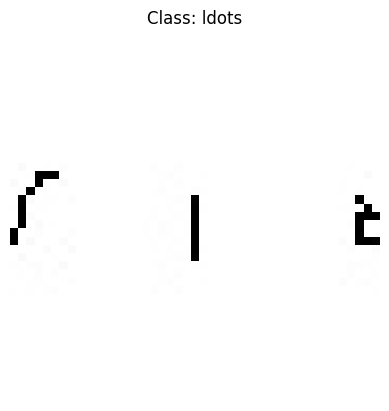

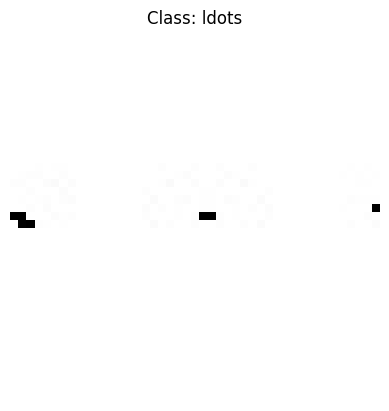

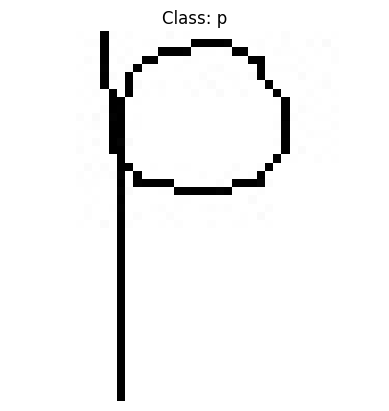

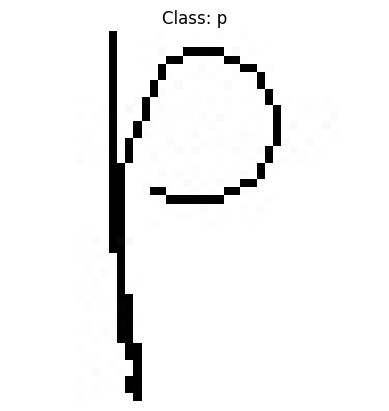

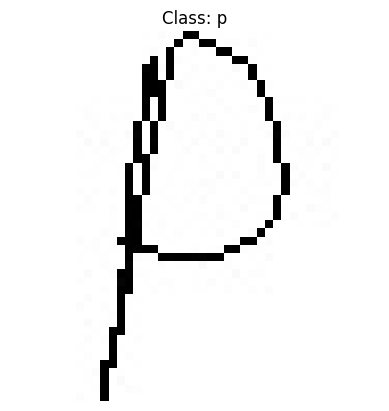

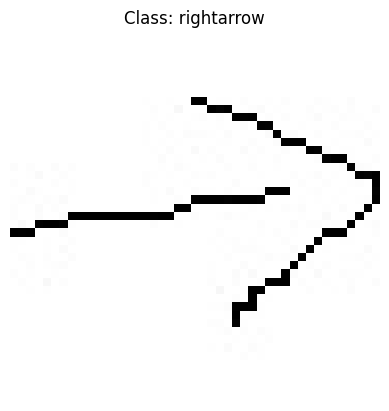

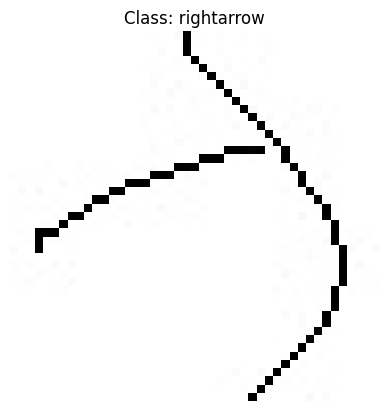

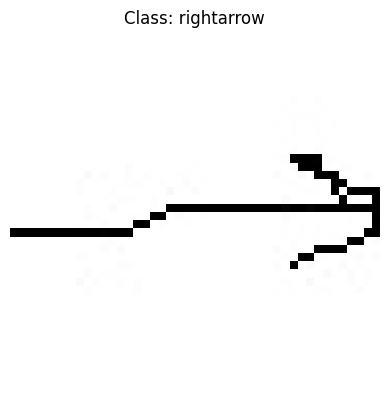

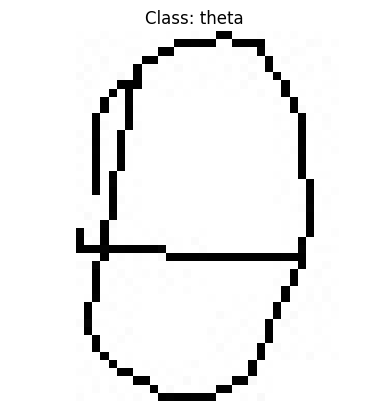

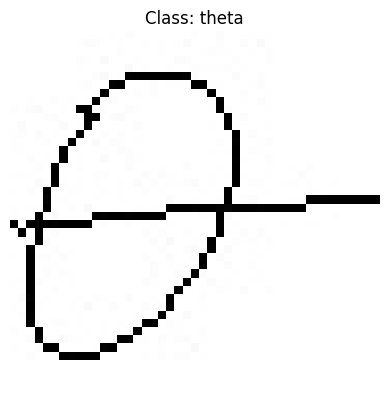

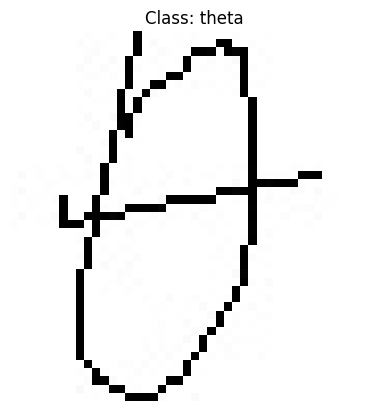

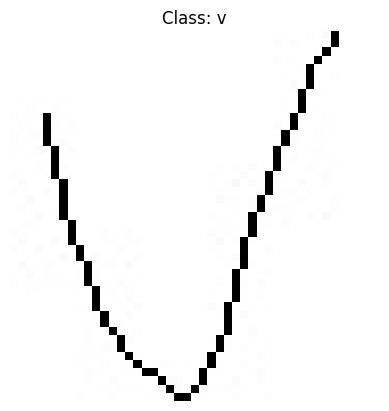

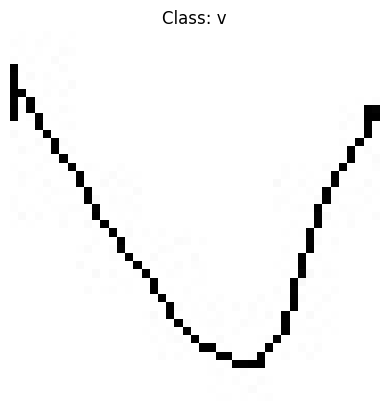

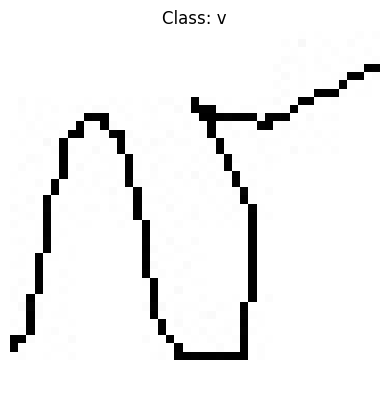

In [20]:
import matplotlib.pyplot as plt

classes = np.unique(labels)  # get all class names

for cls in classes:
    count = 0

    for i in range(len(labels)):
        if labels[i] == cls:
            plt.imshow(images[i], cmap='gray')
            plt.title("Class: " + cls)
            plt.axis('off')
            plt.show()

            count += 1
            if count == 3:
                break

Sample image of each class

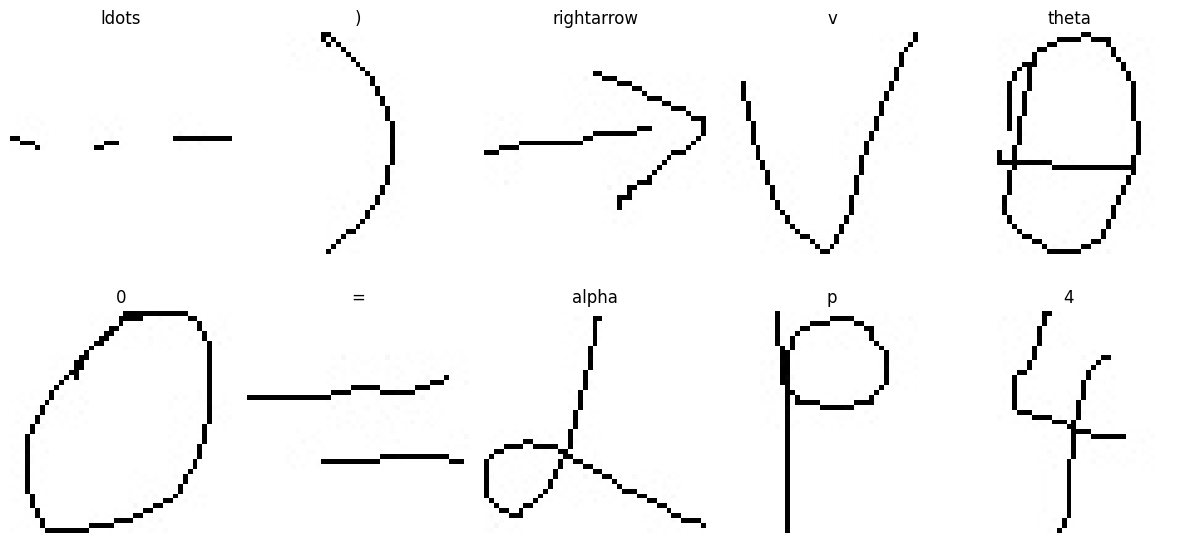

In [21]:
import matplotlib.pyplot as plt
import os
import cv2

class_names = [c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))]

plt.figure(figsize=(12, 6))

for i, class_name in enumerate(class_names[:10]):
    class_path = os.path.join(dataset_path, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

Feature Extraction using three features

---



Raw Pixel Features

In [22]:
X_raw = images.reshape(len(images), -1)
print("Raw feature shape:", X_raw.shape)

Raw feature shape: (5000, 2025)


Histogram of Gradient Descents (HOG)

In [23]:
from skimage import feature
X_hog = []

for img in images:
  hogfeatures = hog(
      img,
      orientations=9,
      pixels_per_cell=(8, 8),
      cells_per_block=(2, 2),
      feature_vector=True
  )
  X_hog.append(hogfeatures)

X_hog = np.array(X_hog)
print("HOG feature shape:", X_hog.shape)


HOG feature shape: (5000, 576)


Local Binary Patterns

In [24]:
X_lbp = []
radius = 1
n_points = 8 * radius

for img in images:
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2, range=(0, n_points + 2))
    hist = hist.astype(float)
    hist /= hist.sum() + 1e-6
    X_lbp.append(hist)

X_lbp = np.array(X_lbp)
print("LBP feature shape:", X_lbp.shape)

LBP feature shape: (5000, 10)


In [29]:
from sklearn.model_selection import train_test_split
import numpy as np

labels = np.array(labels)
indices = np.arange(len(labels))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

y_train = labels[train_idx]
y_test = labels[test_idx]

In [30]:
# RAW
X_train_raw = X_raw[train_idx]
X_test_raw = X_raw[test_idx]

# HOG
X_train_hog = X_hog[train_idx]
X_test_hog = X_hog[test_idx]

# LBP
X_train_lbp = X_lbp[train_idx]
X_test_lbp = X_lbp[test_idx]

Running the SVM

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def svm_testing(X_train, X_test, y_train, y_test, feature_name, kernel='linear', C=1.0):
    print("========== SVM with " + feature_name + " ==========")

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    svm_model = SVC(kernel=kernel, C=C)
    svm_model.fit(X_train, y_train)

    y_pred = svm_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(accuracy, 4))

    return accuracy, y_pred

Running all feature extraction methods using SVM

In [32]:
acc_raw, pred_raw = svm_testing(X_train_raw, X_test_raw, y_train, y_test, "Raw Pixels")
acc_hog, pred_hog = svm_testing(X_train_hog, X_test_hog, y_train, y_test, "HOG")
acc_lbp, pred_lbp = svm_testing(X_train_lbp, X_test_lbp, y_train, y_test, "LBP")



========== SVM with Raw Pixels ==========
Accuracy: 0.9467
========== SVM with HOG ==========
Accuracy: 0.97
========== SVM with LBP ==========
Accuracy: 0.5867


**Summarizing the accuracies of all feature extraction methods**

In [33]:
print("SVM Final results")
print(" ")

print(acc_raw)
print(acc_hog)
print(acc_lbp)

SVM Final results
 
0.9466666666666667
0.97
0.5866666666666667


We will now calculate which feature extraction method brings the highest accuracy

In [34]:
AllResults = [acc_raw, acc_hog, acc_lbp]
Names = ["Raw Pixels", "HOG", "LBP"]

best_result = max(AllResults)
best_index = AllResults.index(best_result)
best_name = Names[best_index]

print("Best feature:", best_name)
print("Best accuracy:", best_result)


Best feature: HOG
Best accuracy: 0.97


Confusion Matrix for the best feature (HOG)

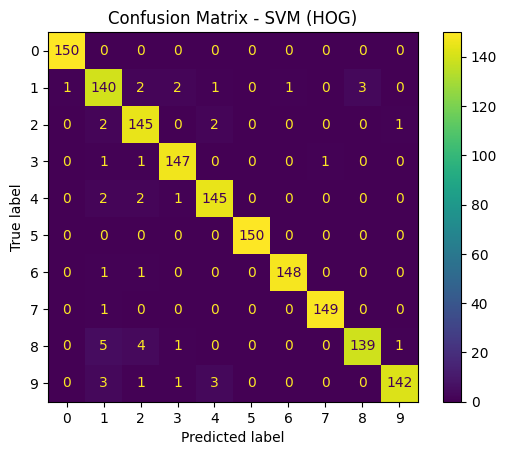

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, pred_hog)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title("Confusion Matrix - SVM (HOG)")
plt.show()